# Basic Agentic RAG using LangGraph

This notebook demonstrates the core foundation of **Agentic RAG** using **LangGraph**. Unlike rigid sequential chains, LangGraph organizes retrieval and response synthesis as discrete, stateful graph nodes.

## Workflow Architecture

<div align="center">
  <img src="workflow_basic_agentic_rag.png" alt="Basic Agentic RAG Architecture Diagram" width="300" />
</div>

<details>
<summary><b>Click to expand Colorful Mermaid Source Code</b></summary>

```mermaid
flowchart TD
    Start(["1. User Question"]):::startNode
    
    subgraph StateGraphRuntime["LangGraph Execution Flow"]
        Retrieve["2. retriever Node<br/><b>FAISS Vector Store</b><br/>(HuggingFace MiniLM Embeddings)"]:::retNode
        Generate["3. responder Node<br/><b>Groq LLM Synthesis</b><br/>(openai/gpt-oss-120b)"]:::genNode
    end
    
    EndNode(["4. Final Grounded Answer"]):::endNode
    
    Start --> Retrieve
    Retrieve --> Generate
    Generate --> EndNode

    classDef startNode fill:#E8F5E9,stroke:#2E7D32,stroke-width:2px,color:#1B5E20;
    classDef retNode fill:#FFF3E0,stroke:#EF6C00,stroke-width:2px,color:#BF360C;
    classDef genNode fill:#F3E5F5,stroke:#7B1FA2,stroke-width:2px,color:#4A148C;
    classDef endNode fill:#FFEBEE,stroke:#D32F2F,stroke-width:2px,color:#B71C1C;
```
</details>

### Pipeline Highlights
- **State Schema**: Explicit typed state tracking questions, retrieved documents, and generated answers.
- **Local Embeddings**: `sentence-transformers/all-MiniLM-L6-v2` via `HuggingFaceEmbeddings`.
- **Groq LLM**: `openai/gpt-oss-120b` for high-throughput grounded synthesis.


## Step 0: Environment Setup

Load environment variables from `.env` and initialize the Groq Chat Model (`openai/gpt-oss-120b`).


In [1]:
import os
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model

# Load environment variables
load_dotenv()
os.environ['USER_AGENT'] = os.getenv('USER_AGENT', 'AgenticRAG/1.0')
os.environ['GROQ_API_KEY'] = os.getenv('GROQ_API_KEY')

# Initialize Groq LLM
llm = init_chat_model('groq:openai/gpt-oss-120b')
print('Groq LLM initialized successfully.')
llm


Groq LLM initialized successfully.


ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.1', 'langchain': '1.3.18'}}, profile={'name': 'GPT OSS 120B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000002D1D9965D30>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002D1D99667B0>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'))

## Step 1: Document Ingestion and Chunking

We ingest authoritative blog posts on autonomous agents and video diffusion using `WebBaseLoader`.


In [2]:
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

urls = [
    'https://lilianweng.github.io/posts/2023-06-23-agent/',
    'https://lilianweng.github.io/posts/2024-04-12-diffusion-video/',
]

loaders = [WebBaseLoader(url) for url in urls]
doc = []
for loader in loaders:
    doc.extend(loader.load())

splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=100)
chunks = splitter.split_documents(doc)
print(f'Loaded {len(doc)} documents and split into {len(chunks)} chunks.')


C:\Users\itsar\AppData\Local\Temp\ipykernel_43656\3801359980.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import WebBaseLoader
c:\RAG\Code\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded 2 documents and split into 235 chunks.


## Step 2: Vector Indexing with HuggingFace Embeddings

We embed the chunks using `sentence-transformers/all-MiniLM-L6-v2` into an in-memory **FAISS** vector store.


In [3]:
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS

embeddings = HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2')
vectorstore = FAISS.from_documents(chunks, embeddings)
retriever = vectorstore.as_retriever()
print(f'Indexed {vectorstore.index.ntotal} vectors into FAISS.')


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6109.13it/s]


Indexed 235 vectors into FAISS.


## Step 3: Define RAG State

We define `RAGState` (`TypedDict`) to represent the data passed between nodes in the graph.


In [4]:
from typing import List
from typing_extensions import TypedDict
from langchain_core.documents import Document

class RAGState(TypedDict):
    question: str
    retrieve_doc: List[Document]
    answer: str

print('RAGState defined successfully.')


RAGState defined successfully.


## Step 4: Define Graph Nodes

We implement the two core nodes:
1. **`retrieve_doc`**: Fetches relevant context chunks from FAISS.
2. **`generate_answer`**: Synthesizes the grounded answer via the Groq LLM.


In [5]:
def retrieve_doc(state: RAGState) -> RAGState:
    print('--- [NODE: RETRIEVER] Fetching documents ---')
    docs = retriever.invoke(state['question'])
    return {'question': state['question'], 'retrieve_doc': docs, 'answer': state.get('answer', '')}

def generate_answer(state: RAGState) -> RAGState:
    print('--- [NODE: RESPONDER] Synthesizing answer ---')
    context = '\n\n'.join([d.page_content for d in state['retrieve_doc']])
    prompt = f'Answer the question concisely based strictly on the context.\n\nContext:\n{context}\n\nQuestion: {state["question"]}'
    response = llm.invoke(prompt)
    return {'question': state['question'], 'retrieve_doc': state['retrieve_doc'], 'answer': response.content}

print('Nodes defined successfully.')


Nodes defined successfully.


## Step 5: Assemble and Compile LangGraph Workflow

We construct the `StateGraph(RAGState)` and compile the executable graph.


Basic Agentic RAG graph compiled successfully!



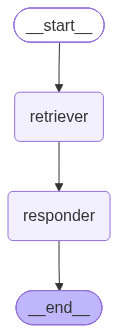

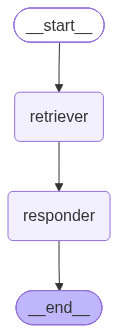

In [6]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

builder = StateGraph(RAGState)
builder.add_node('retriever', retrieve_doc)
builder.add_node('responder', generate_answer)

builder.add_edge(START, 'retriever')
builder.add_edge('retriever', 'responder')
builder.add_edge('responder', END)

graph = builder.compile()
print('Basic Agentic RAG graph compiled successfully!\n')
display(Image(graph.get_graph().draw_mermaid_png()))
graph


## Step 6: End-to-End Pipeline Execution

We invoke the compiled graph with a domain query: *"What is the concept of agent loop in autonomous agents?"*


In [7]:
user_question = 'What is the concept of agent loop in autonomous agents?'
print('=' * 75)
print(f'USER QUESTION: {user_question}')
print('=' * 75)

final_state = graph.invoke({'question': user_question, 'retrieve_doc': [], 'answer': ''})

print('\n' + '=' * 75)
print('FINAL GROUNDED ANSWER:')
print('=' * 75)
print(final_state['answer'])


USER QUESTION: What is the concept of agent loop in autonomous agents?
--- [NODE: RETRIEVER] Fetching documents ---
--- [NODE: RESPONDER] Synthesizing answer ---

FINAL GROUNDED ANSWER:
The agent loop is the iterative cycle that an autonomous LLM‑powered agent follows: it repeatedly **observes the environment**, **computes a heuristic $h_t$**, **reflects on its performance**, **plans/re‑acts by translating reflections and environment information into actions**, executes those actions, and—if its self‑reflection deems it necessary—**resets the environment to start a new trial** before looping again. This continual sense‑think‑act‑reset process constitutes the core “agent loop.”


## Summary

| Component | Technology | Role |
|---|---|---|
| **Embeddings** | HuggingFace `sentence-transformers/all-MiniLM-L6-v2` | Dense 384-dimensional vector representations |
| **Vector Store** | FAISS | In-memory similarity search over ingested articles |
| **LLM Engine** | Groq `openai/gpt-oss-120b` (`init_chat_model`) | Fast high-throughput answer synthesis |
| **Orchestration** | LangGraph `StateGraph` | Discrete node-based RAG workflow execution |
